### Cell 1: 라이브러리

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


### Cell 2: 데이터 로드 + 피처 그룹 정의

In [52]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv")
df_clean = df.dropna().copy()

df_clean['ProtectiveStop_bool'] = df_clean['Robot_ProtectiveStop'].apply(
    lambda x: True if str(x).strip().lower() == 'true' else False
)

# 피처 그룹
current_cols = ['Current_J0', 'Current_J1', 'Current_J2',
                'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']
speed_cols   = ['Speed_J0', 'Speed_J1', 'Speed_J2',
                'Speed_J3', 'Speed_J4', 'Speed_J5']
temp_cols    = ['Temperature_T0', 'Temperature_J1', 'Temperature_J2',
                'Temperature_J3', 'Temperature_J4', 'Temperature_J5']
df_clean['Temperature_Mean'] = df_clean[temp_cols].mean(axis=1)

group_A = current_cols                           # 7개
group_B = current_cols + speed_cols              # 13개
#group_C = current_cols + speed_cols + temp_cols   # 19개
group_C = current_cols + speed_cols + ['Temperature_Mean']   # 14개


groups = {
    'Group A (Current, 7)':       group_A,
    'Group B (Current+Speed, 13)': group_B,
    'Group C (All, 19)':           group_C
}

print(f"데이터: {len(df_clean)}행 × {len(df_clean.columns)}열")
for name, cols in groups.items():
    print(f"  {name}: {cols}")

데이터: 7355행 × 26열
  Group A (Current, 7): ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']
  Group B (Current+Speed, 13): ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
  Group C (All, 19): ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5', 'Temperature_Mean']


### Cell 3: 스케일링 (3개 그룹 한번에)

In [53]:
scalers = {}
X_scaled = {}

for name, cols in groups.items():
    scaler = StandardScaler()
    X_scaled[name] = scaler.fit_transform(df_clean[cols].values)
    scalers[name] = scaler
    print(f"{name}: {X_scaled[name].shape}")

print("\n✅ StandardScaler 적용 완료")

Group A (Current, 7): (7355, 7)
Group B (Current+Speed, 13): (7355, 13)
Group C (All, 19): (7355, 14)

✅ StandardScaler 적용 완료


## Group A: Current (7 features)
`Current_J0~J5` + `Tool_current` — 로봇의 전기적 부하 상태.
각 관절의 전류는 해당 관절이 받는 물리적 부하를 직접 반영한다.

### Cell 5: Group A — Elbow + Silhouette

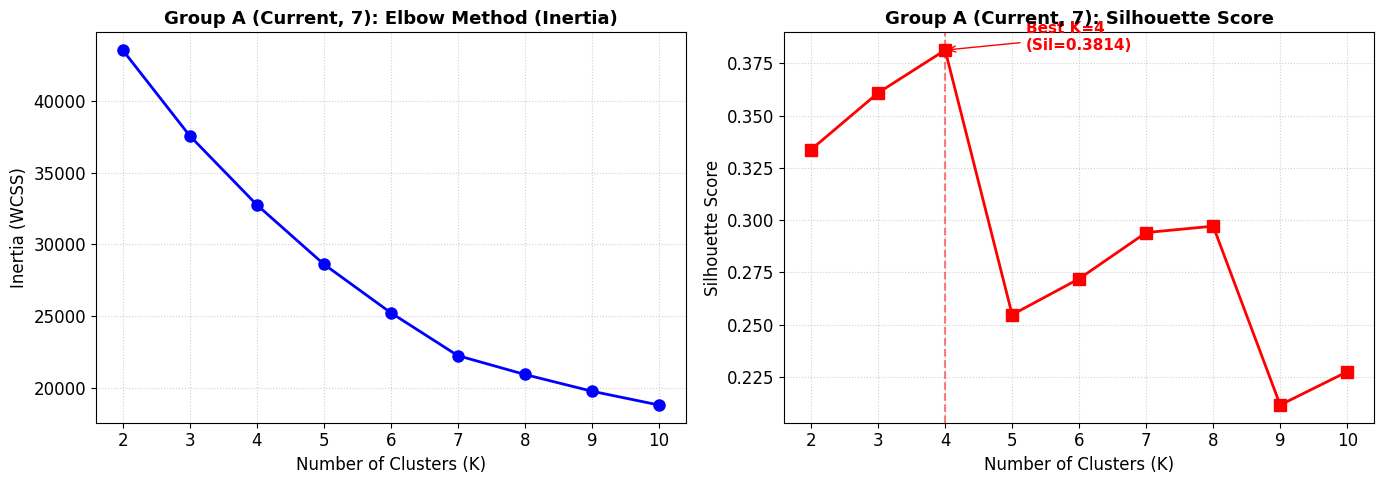


[Group A (Current, 7)] K값별 Silhouette Score:
  K= 2 → Silhouette = 0.3338
  K= 3 → Silhouette = 0.3609
  K= 4 → Silhouette = 0.3814 ◀ BEST
  K= 5 → Silhouette = 0.2548
  K= 6 → Silhouette = 0.2720
  K= 7 → Silhouette = 0.2940
  K= 8 → Silhouette = 0.2971
  K= 9 → Silhouette = 0.2116
  K=10 → Silhouette = 0.2275


In [6]:
K_range = range(2, 11)
name = 'Group A (Current, 7)'
X = X_scaled[name]

inertias_A, sil_scores_A = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias_A.append(km.inertia_)
    sil_scores_A.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias_A, 'bo-', linewidth=2, markersize=8)
axes[0].set_title(f'{name}: Elbow Method (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(K_range, sil_scores_A, 'rs-', linewidth=2, markersize=8)
axes[1].set_title(f'{name}: Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, linestyle=':', alpha=0.6)

best_k_A = list(K_range)[np.argmax(sil_scores_A)]
axes[1].axvline(x=best_k_A, color='red', linestyle='--', alpha=0.5)
axes[1].annotate(f'Best K={best_k_A}\n(Sil={max(sil_scores_A):.4f})',
                 xy=(best_k_A, max(sil_scores_A)),
                 xytext=(best_k_A + 1.2, max(sil_scores_A)),
                 fontsize=11, fontweight='bold', color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
plt.show()

print(f"\n[{name}] K값별 Silhouette Score:")
for k, s in zip(K_range, sil_scores_A):
    marker = " ◀ BEST" if k == best_k_A else ""
    print(f"  K={k:2d} → Silhouette = {s:.4f}{marker}")

### Cell 6: Group A — K-Means 학습 + PCA 시각화

[Group A] K-Means (K=4)
  Silhouette Score = 0.3814
  Inertia = 32767.10


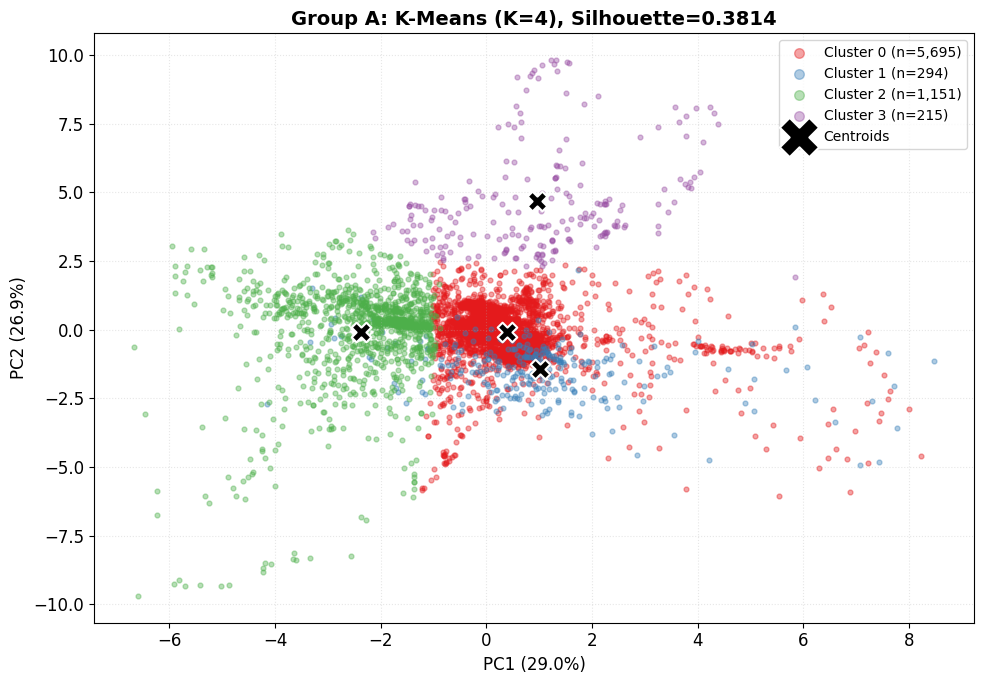

In [7]:
# K-Means 학습
OPTIMAL_K_A = best_k_A  # ⚠️ 필요시 수동 조정
km_A = KMeans(n_clusters=OPTIMAL_K_A, n_init=10, random_state=42)
labels_A = km_A.fit_predict(X_scaled[name])
sil_A = silhouette_score(X_scaled[name], labels_A)

print(f"[Group A] K-Means (K={OPTIMAL_K_A})")
print(f"  Silhouette Score = {sil_A:.4f}")
print(f"  Inertia = {km_A.inertia_:.2f}")

# PCA 2D 시각화
pca_A = PCA(n_components=2, random_state=42)
X_pca_A = pca_A.fit_transform(X_scaled[name])

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.Set1
for c_id in range(OPTIMAL_K_A):
    mask = labels_A == c_id
    count = mask.sum()
    ax.scatter(X_pca_A[mask, 0], X_pca_A[mask, 1],
               c=[cmap(c_id)], alpha=0.4, s=12,
               label=f'Cluster {c_id} (n={count:,})')

# 중심점 표시
centers_pca = pca_A.transform(km_A.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=200, edgecolors='white', linewidths=1.5,
           zorder=10, label='Centroids')

ax.set_title(f'Group A: K-Means (K={OPTIMAL_K_A}), Silhouette={sil_A:.4f}',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_A.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_A.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=10, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 7: Group A — 군집 프로파일링

[Group A] K-Means (K=4) — 군집별 피처 평균
              Current_J0  Current_J1  Current_J2  Current_J3  Current_J4  Current_J5  Tool_current
KM_Cluster_A                                                                                      
0                -0.0241     -2.0719     -1.0470     -0.5000     -0.0349     -0.0005        0.0970
1                 0.1684     -1.9608     -0.9146     -0.5124     -0.3836     -0.0335        0.4595
2                 0.2960     -3.4484     -1.9725     -1.2489     -0.2406      0.0228        0.0863
3                -2.8884     -2.5870     -1.4865     -0.0757      1.9522     -0.0329        0.0868

[군집 크기]
  Cluster 0: 5,695개 (77.4%)
  Cluster 1: 294개 (4.0%)
  Cluster 2: 1,151개 (15.6%)
  Cluster 3: 215개 (2.9%)


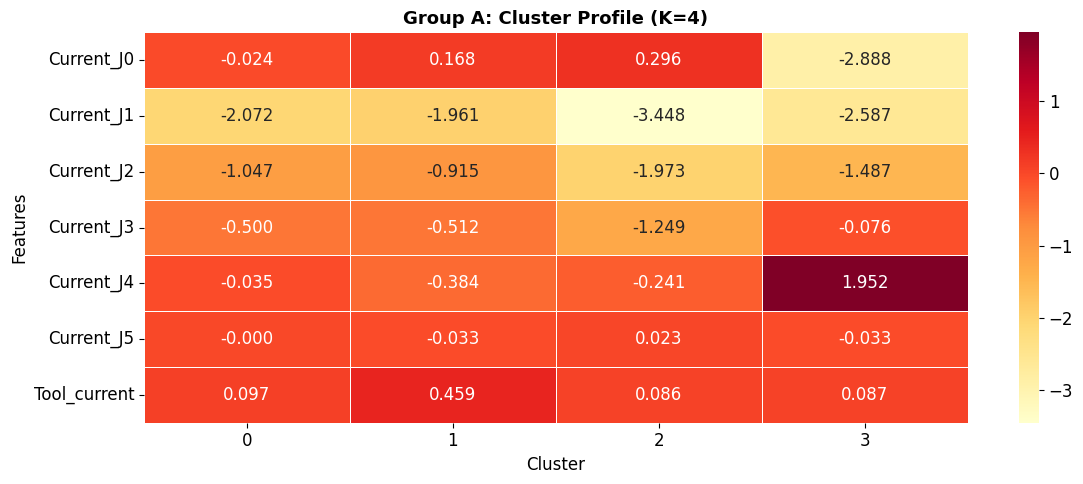

In [8]:
df_clean['KM_Cluster_A'] = labels_A

# 군집별 피처 평균
profile_A = df_clean.groupby('KM_Cluster_A')[group_A].mean()

print(f"{'='*70}")
print(f"[Group A] K-Means (K={OPTIMAL_K_A}) — 군집별 피처 평균")
print(f"{'='*70}")
print(profile_A.round(4).to_string())

# 군집별 크기
print(f"\n[군집 크기]")
for c_id in range(OPTIMAL_K_A):
    n = (labels_A == c_id).sum()
    pct = n / len(labels_A) * 100
    print(f"  Cluster {c_id}: {n:,}개 ({pct:.1f}%)")

# 히트맵
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_A.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title(f'Group A: Cluster Profile (K={OPTIMAL_K_A})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Features')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

### Cell 8: Group A — Silhouette 샘플 분석

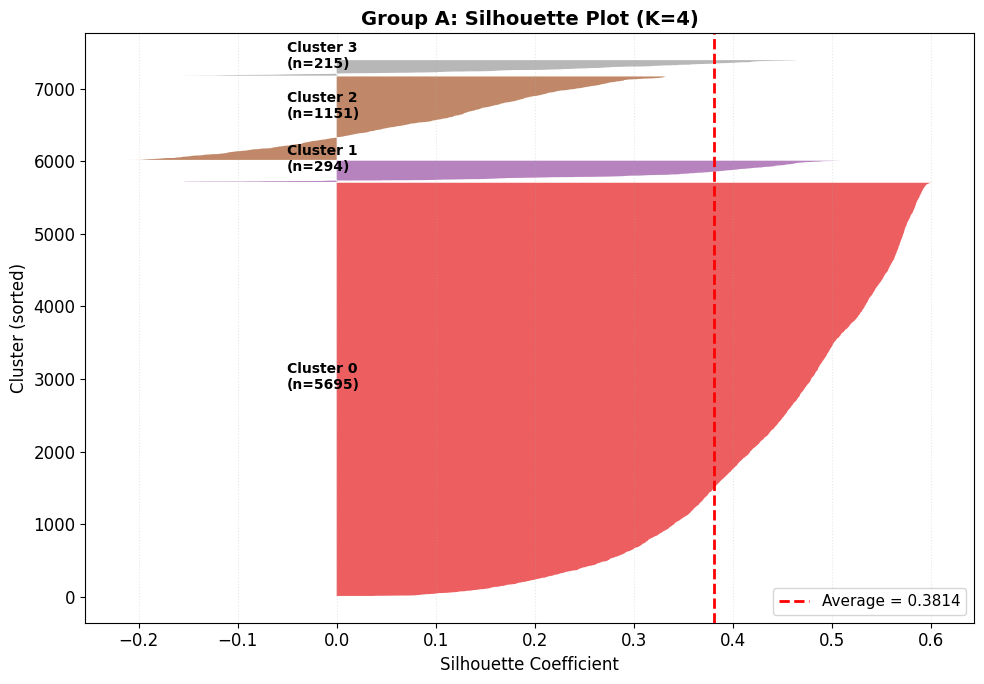

[군집별 Silhouette 통계]
  Cluster 0: mean=0.4484, min=0.0371, 음수비율=0.0%
  Cluster 1: mean=0.3281, min=-0.1543, 음수비율=6.8%
  Cluster 2: mean=0.0914, min=-0.2129, 음수비율=26.9%
  Cluster 3: mean=0.2298, min=-0.1566, 음수비율=13.0%


In [9]:
sil_samples_A = silhouette_samples(X_scaled[name], labels_A)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
colors = plt.cm.Set1(np.linspace(0, 1, OPTIMAL_K_A))

for c_id in range(OPTIMAL_K_A):
    cluster_sil = sil_samples_A[labels_A == c_id]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[c_id], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {c_id}\n(n={size})',
            fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_A, color='red', linestyle='--', linewidth=2,
           label=f'Average = {sil_A:.4f}')
ax.set_title(f'Group A: Silhouette Plot (K={OPTIMAL_K_A})', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster (sorted)')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, linestyle=':', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 군집별 실루엣 통계
print("[군집별 Silhouette 통계]")
for c_id in range(OPTIMAL_K_A):
    s = sil_samples_A[labels_A == c_id]
    neg_pct = (s < 0).sum() / len(s) * 100
    print(f"  Cluster {c_id}: mean={s.mean():.4f}, min={s.min():.4f}, 음수비율={neg_pct:.1f}%")

## Group B: Current + Speed (13 features)
전류 7개 + 속도 6개 — 속도를 추가하면 "같은 전류라도 다른 동작 상태"를 구분할 수 있는지 확인.

### Cell 10: Group B — Elbow + Silhouette

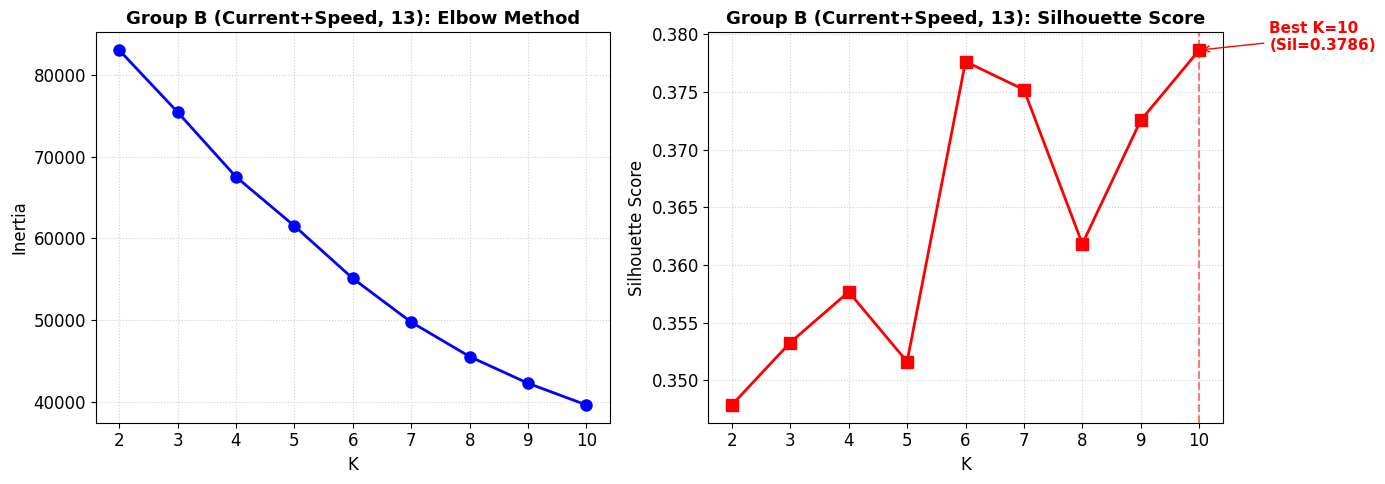


[Group B (Current+Speed, 13)] K값별 Silhouette Score:
  K= 2 → Silhouette = 0.3479
  K= 3 → Silhouette = 0.3533
  K= 4 → Silhouette = 0.3577
  K= 5 → Silhouette = 0.3516
  K= 6 → Silhouette = 0.3776
  K= 7 → Silhouette = 0.3752
  K= 8 → Silhouette = 0.3618
  K= 9 → Silhouette = 0.3726
  K=10 → Silhouette = 0.3786 ◀ BEST


In [10]:
name_B = 'Group B (Current+Speed, 13)'
X_B = X_scaled[name_B]

inertias_B, sil_scores_B = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_B)
    inertias_B.append(km.inertia_)
    sil_scores_B.append(silhouette_score(X_B, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias_B, 'bo-', linewidth=2, markersize=8)
axes[0].set_title(f'{name_B}: Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range)); axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(K_range, sil_scores_B, 'rs-', linewidth=2, markersize=8)
axes[1].set_title(f'{name_B}: Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range)); axes[1].grid(True, linestyle=':', alpha=0.6)

best_k_B = list(K_range)[np.argmax(sil_scores_B)]
axes[1].axvline(x=best_k_B, color='red', linestyle='--', alpha=0.5)
axes[1].annotate(f'Best K={best_k_B}\n(Sil={max(sil_scores_B):.4f})',
                 xy=(best_k_B, max(sil_scores_B)),
                 xytext=(best_k_B + 1.2, max(sil_scores_B)),
                 fontsize=11, fontweight='bold', color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
plt.show()

print(f"\n[{name_B}] K값별 Silhouette Score:")
for k, s in zip(K_range, sil_scores_B):
    marker = " ◀ BEST" if k == best_k_B else ""
    print(f"  K={k:2d} → Silhouette = {s:.4f}{marker}")

### Cell 11: Group B — K-Means + PCA

[Group B] K-Means (K=4), Silhouette = 0.3577


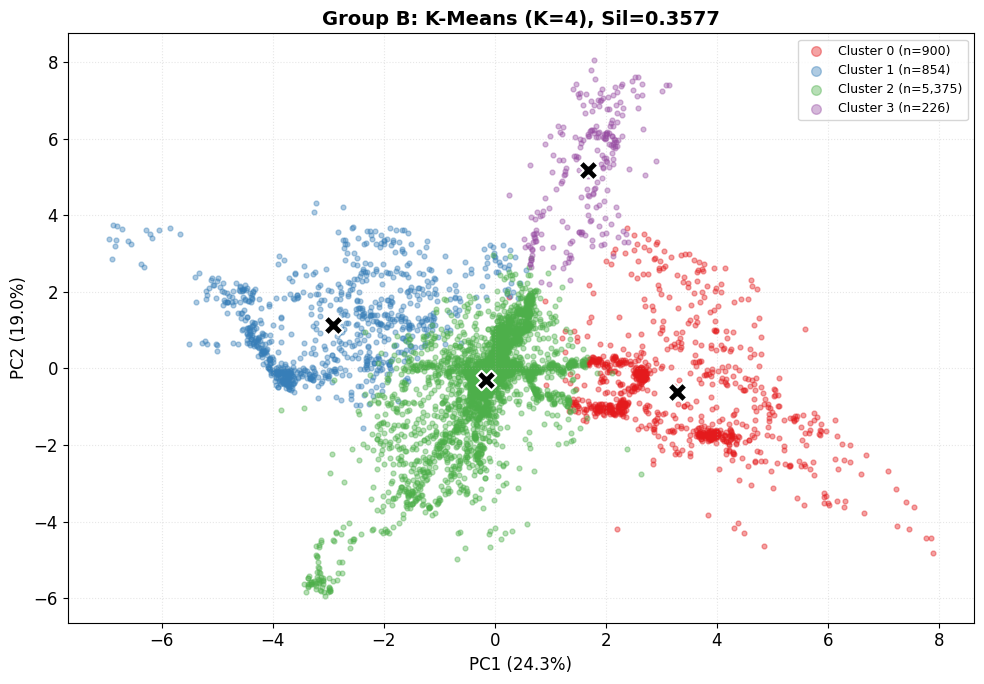

In [14]:
OPTIMAL_K_B = 4#best_k_B  # ⚠️ 필요시 수동 조정 (K=10이면 K=4로 고정 권장)
km_B = KMeans(n_clusters=OPTIMAL_K_B, n_init=10, random_state=42)
labels_B = km_B.fit_predict(X_B)
sil_B = silhouette_score(X_B, labels_B)

print(f"[Group B] K-Means (K={OPTIMAL_K_B}), Silhouette = {sil_B:.4f}")

pca_B = PCA(n_components=2, random_state=42)
X_pca_B = pca_B.fit_transform(X_B)

fig, ax = plt.subplots(figsize=(10, 7))
for c_id in range(OPTIMAL_K_B):
    mask = labels_B == c_id
    ax.scatter(X_pca_B[mask, 0], X_pca_B[mask, 1],
               c=[plt.cm.Set1(c_id % 10)], alpha=0.4, s=12,
               label=f'Cluster {c_id} (n={mask.sum():,})')

centers_pca_B = pca_B.transform(km_B.cluster_centers_)
ax.scatter(centers_pca_B[:, 0], centers_pca_B[:, 1],
           c='black', marker='X', s=200, edgecolors='white', linewidths=1.5, zorder=10)
ax.set_title(f'Group B: K-Means (K={OPTIMAL_K_B}), Sil={sil_B:.4f}', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_B.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_B.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2, loc='best')
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 12: Group B — 프로파일링 + Silhouette 샘플

[Group B] 군집별 피처 평균 (K=4)
              Current_J0  Current_J1  Current_J2  Current_J3  Current_J4  Current_J5  Tool_current  Speed_J0  Speed_J1  Speed_J2  Speed_J3  Speed_J4  Speed_J5
KM_Cluster_B                                                                                                                                                  
0                -0.7616     -2.5376     -1.8926     -0.1911      0.3274     -0.0816        0.0860   -0.0019    0.0587   -0.8826    0.5382   -0.0144   -0.5407
1                 0.8168     -2.7013     -1.1847     -1.1501     -0.4473      0.0887        0.0887    0.0389   -0.0386    0.8155   -0.5554    0.0158    0.5243
2                -0.0583     -2.1479     -1.0601     -0.5946     -0.0060     -0.0092        0.1170    0.0138   -0.0002    0.0259   -0.0346   -0.0070    0.0182
3                -0.2973     -3.3878     -1.8075     -0.4512     -0.2173      0.2390        0.1049   -0.4133   -0.0811   -0.0592    0.6288    0.1371   -0.1662


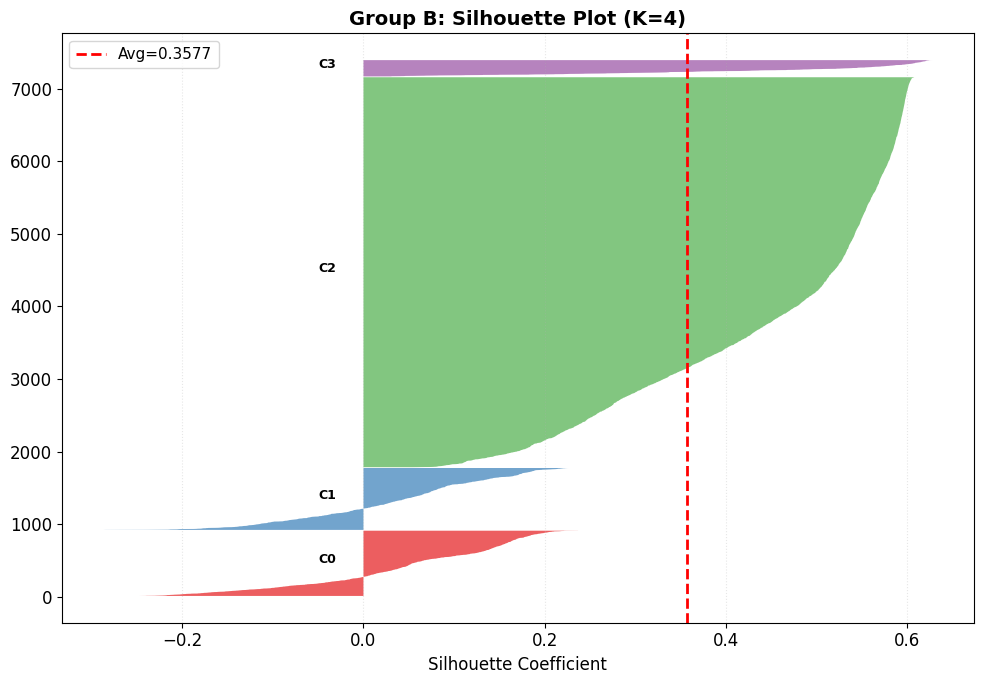

In [15]:
df_clean['KM_Cluster_B'] = labels_B

profile_B = df_clean.groupby('KM_Cluster_B')[group_B].mean()
print(f"[Group B] 군집별 피처 평균 (K={OPTIMAL_K_B})")
print(profile_B.round(4).to_string())

# Silhouette 샘플
sil_samples_B = silhouette_samples(X_B, labels_B)
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for c_id in range(OPTIMAL_K_B):
    cluster_sil = np.sort(sil_samples_B[labels_B == c_id])
    size = len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_lower + size), 0, cluster_sil,
                     facecolor=plt.cm.Set1(c_id % 10), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'C{c_id}', fontsize=9, fontweight='bold')
    y_lower += size + 10

ax.axvline(x=sil_B, color='red', linestyle='--', linewidth=2, label=f'Avg={sil_B:.4f}')
ax.set_title(f'Group B: Silhouette Plot (K={OPTIMAL_K_B})', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Group C: All 19 features
전류 7 + 속도 6 + 온도 6 — 모든 센서 변수를 포함.
온도 6개의 다중공선성(r=0.99+)이 클러스터링에 미치는 영향을 확인.

### Cell 14: Group C — Elbow + Silhouette

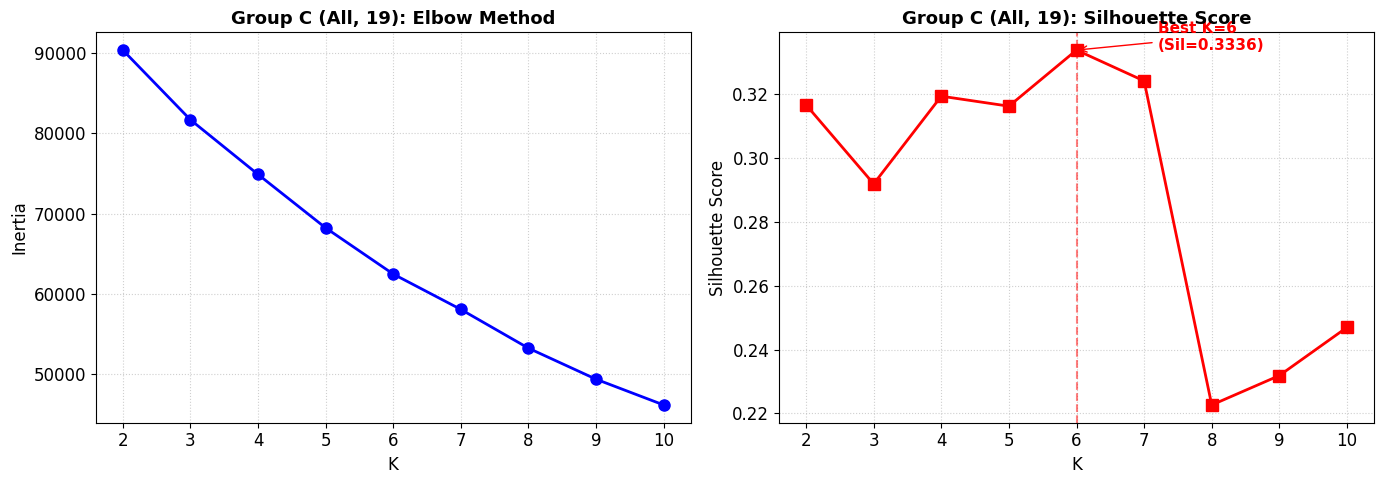


[Group C (All, 19)] K값별 Silhouette Score:
  K= 2 → Silhouette = 0.3165
  K= 3 → Silhouette = 0.2918
  K= 4 → Silhouette = 0.3192
  K= 5 → Silhouette = 0.3161
  K= 6 → Silhouette = 0.3336 ◀ BEST
  K= 7 → Silhouette = 0.3240
  K= 8 → Silhouette = 0.2226
  K= 9 → Silhouette = 0.2319
  K=10 → Silhouette = 0.2469


In [54]:
name_C = 'Group C (All, 19)'
X_C = X_scaled[name_C]

inertias_C, sil_scores_C = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_C)
    inertias_C.append(km.inertia_)
    sil_scores_C.append(silhouette_score(X_C, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias_C, 'bo-', linewidth=2, markersize=8)
axes[0].set_title(f'{name_C}: Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range)); axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(K_range, sil_scores_C, 'rs-', linewidth=2, markersize=8)
axes[1].set_title(f'{name_C}: Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range)); axes[1].grid(True, linestyle=':', alpha=0.6)

best_k_C = list(K_range)[np.argmax(sil_scores_C)]
axes[1].axvline(x=best_k_C, color='red', linestyle='--', alpha=0.5)
axes[1].annotate(f'Best K={best_k_C}\n(Sil={max(sil_scores_C):.4f})',
                 xy=(best_k_C, max(sil_scores_C)),
                 xytext=(best_k_C + 1.2, max(sil_scores_C)),
                 fontsize=11, fontweight='bold', color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
plt.show()

print(f"\n[{name_C}] K값별 Silhouette Score:")
for k, s in zip(K_range, sil_scores_C):
    marker = " ◀ BEST" if k == best_k_C else ""
    print(f"  K={k:2d} → Silhouette = {s:.4f}{marker}")

### Cell 15: Group C — K-Means + PCA

[Group C] K-Means (K=4), Silhouette = 0.3192


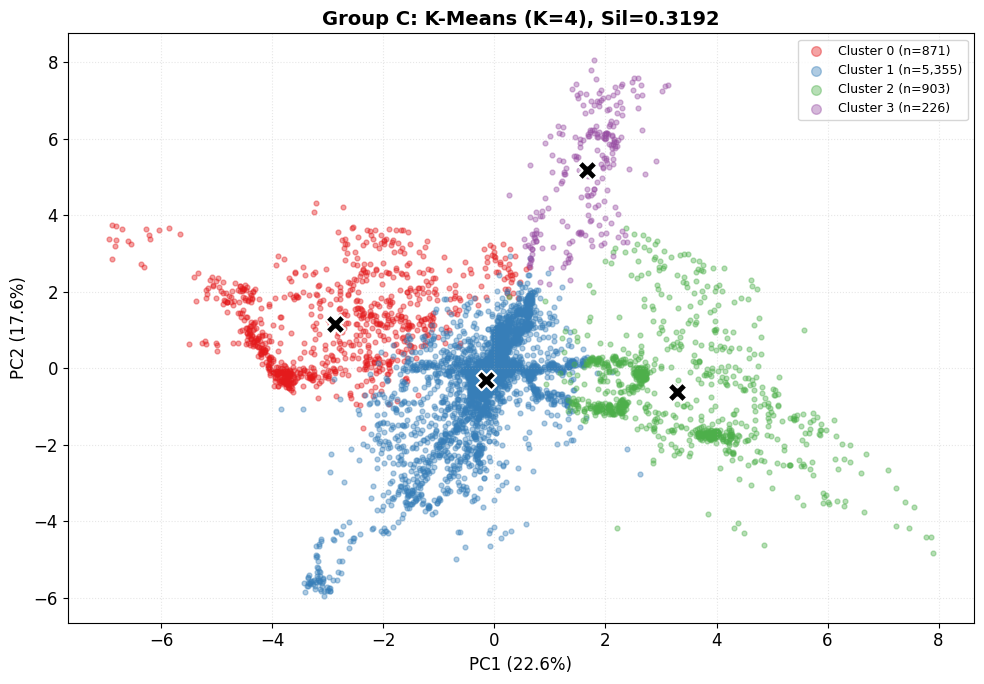

In [57]:
OPTIMAL_K_C = 4#best_k_C
km_C = KMeans(n_clusters=OPTIMAL_K_C, n_init=10, random_state=42)
labels_C = km_C.fit_predict(X_C)
sil_C = silhouette_score(X_C, labels_C)

print(f"[Group C] K-Means (K={OPTIMAL_K_C}), Silhouette = {sil_C:.4f}")

pca_C = PCA(n_components=2, random_state=42)
X_pca_C = pca_C.fit_transform(X_C)

fig, ax = plt.subplots(figsize=(10, 7))
for c_id in range(OPTIMAL_K_C):
    mask = labels_C == c_id
    ax.scatter(X_pca_C[mask, 0], X_pca_C[mask, 1],
               c=[plt.cm.Set1(c_id % 10)], alpha=0.4, s=12,
               label=f'Cluster {c_id} (n={mask.sum():,})')

centers_pca_C = pca_C.transform(km_C.cluster_centers_)
ax.scatter(centers_pca_C[:, 0], centers_pca_C[:, 1],
           c='black', marker='X', s=200, edgecolors='white', linewidths=1.5, zorder=10)
ax.set_title(f'Group C: K-Means (K={OPTIMAL_K_C}), Sil={sil_C:.4f}', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_C.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_C.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2, loc='best')
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 16: Group C — 프로파일링 + Silhouette 샘플

[Group C] 군집별 피처 평균 (K=4)
              Current_J0  Current_J1  Current_J2  Current_J3  Current_J4  Current_J5  Tool_current  Speed_J0  Speed_J1  Speed_J2  Speed_J3  Speed_J4  Speed_J5  Temperature_Mean
KM_Cluster_C                                                                                                                                                                    
0                 0.8156     -2.7171     -1.2061     -1.1570     -0.4458      0.0873        0.0891    0.0386   -0.0388    0.7947   -0.5451    0.0153    0.5138           39.1729
1                -0.0609     -2.1434     -1.0558     -0.5916     -0.0051     -0.0092        0.1170    0.0138   -0.0001    0.0268   -0.0348   -0.0070    0.0184           39.3919
2                -0.7592     -2.5376     -1.8923     -0.1928      0.3276     -0.0819        0.0860   -0.0019    0.0586   -0.8798    0.5372   -0.0143   -0.5395           39.2301
3                -0.2973     -3.3878     -1.8075     -0.4512     -0.2173      0.2390     

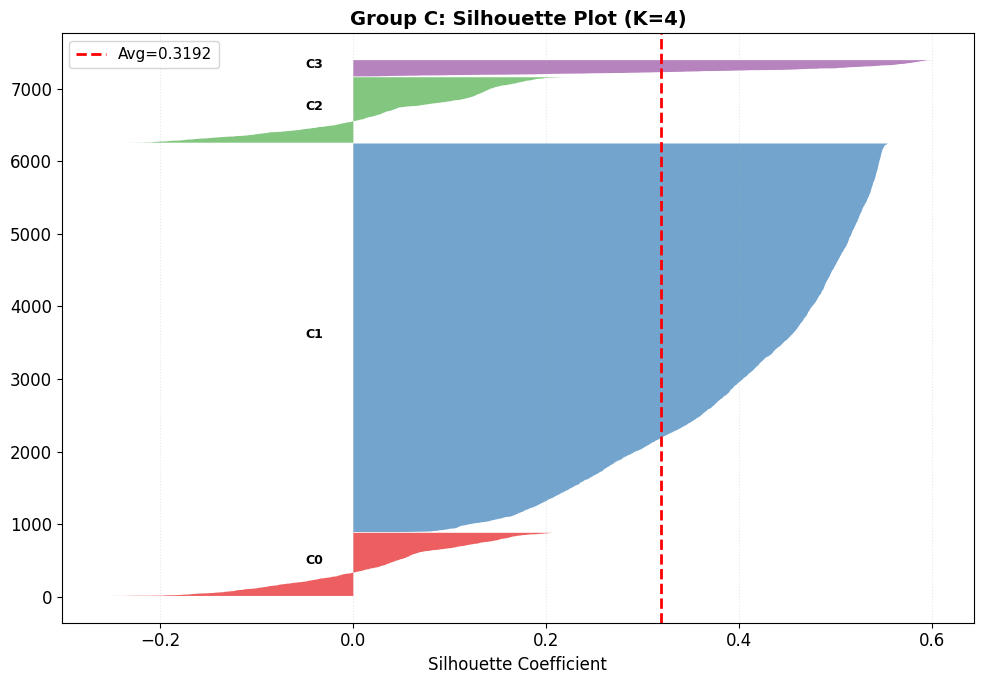

In [58]:
df_clean['KM_Cluster_C'] = labels_C

profile_C = df_clean.groupby('KM_Cluster_C')[group_C].mean()
print(f"[Group C] 군집별 피처 평균 (K={OPTIMAL_K_C})")
print(profile_C.round(4).to_string())

sil_samples_C = silhouette_samples(X_C, labels_C)
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for c_id in range(OPTIMAL_K_C):
    cluster_sil = np.sort(sil_samples_C[labels_C == c_id])
    size = len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_lower + size), 0, cluster_sil,
                     facecolor=plt.cm.Set1(c_id % 10), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'C{c_id}', fontsize=9, fontweight='bold')
    y_lower += size + 10

ax.axvline(x=sil_C, color='red', linestyle='--', linewidth=2, label=f'Avg={sil_C:.4f}')
ax.set_title(f'Group C: Silhouette Plot (K={OPTIMAL_K_C})', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 종합 비교 + 외부 검증

### Cell 17: 3개 그룹 종합 비교

   K-Means 종합 비교: Feature Group별 성능
                Group  K  Silhouette      Inertia
       A (Current, 7)  4    0.381350 32767.102611
B (Current+Speed, 13)  4    0.357677 67539.794358
          C (All, 19)  4    0.310514 88506.833029


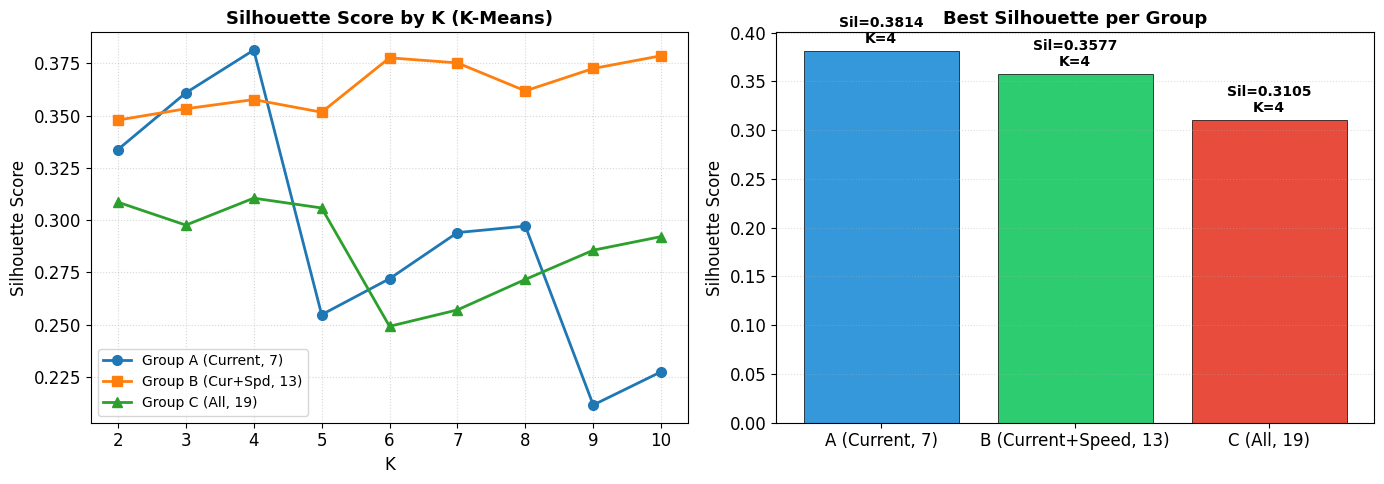


🏆 K-Means 최적 그룹: A (Current, 7)


In [19]:
# ── 종합 비교 ──
summary = pd.DataFrame({
    'Group': ['A (Current, 7)', 'B (Current+Speed, 13)', 'C (All, 19)'],
    'K': [OPTIMAL_K_A, OPTIMAL_K_B, OPTIMAL_K_C],
    'Silhouette': [sil_A, sil_B, sil_C],
    'Inertia': [km_A.inertia_, km_B.inertia_, km_C.inertia_]
})
print("=" * 60)
print("   K-Means 종합 비교: Feature Group별 성능")
print("=" * 60)
print(summary.to_string(index=False))

# Silhouette 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 그룹별 Silhouette 추이
axes[0].plot(K_range, sil_scores_A, 'o-', linewidth=2, markersize=7, label='Group A (Current, 7)')
axes[0].plot(K_range, sil_scores_B, 's-', linewidth=2, markersize=7, label='Group B (Cur+Spd, 13)')
axes[0].plot(K_range, sil_scores_C, '^-', linewidth=2, markersize=7, label='Group C (All, 19)')
axes[0].set_title('Silhouette Score by K (K-Means)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(list(K_range))
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.5)

# (우) 최적 K에서의 Bar 비교
bars = axes[1].bar(summary['Group'], summary['Silhouette'],
                   color=['#3498db', '#2ecc71', '#e74c3c'],
                   edgecolor='black', linewidth=0.5)
for bar, val, k in zip(bars, summary['Silhouette'], summary['K']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'Sil={val:.4f}\nK={k}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Best Silhouette per Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

best_group = summary.loc[summary['Silhouette'].idxmax(), 'Group']
print(f"\n🏆 K-Means 최적 그룹: {best_group}")

### Cell 18: 최적 그룹 — 외부 검증 (에러 라벨)

[외부 검증] K-Means 최적 그룹 — 군집별 에러 발생률
         Total  Grip Lost (%)  Protective Stop (%)
Cluster                                           
0         5695           4.09                 1.84
1          294           0.68                 1.02
2         1151           0.52                14.34
3          215           0.93                 2.33


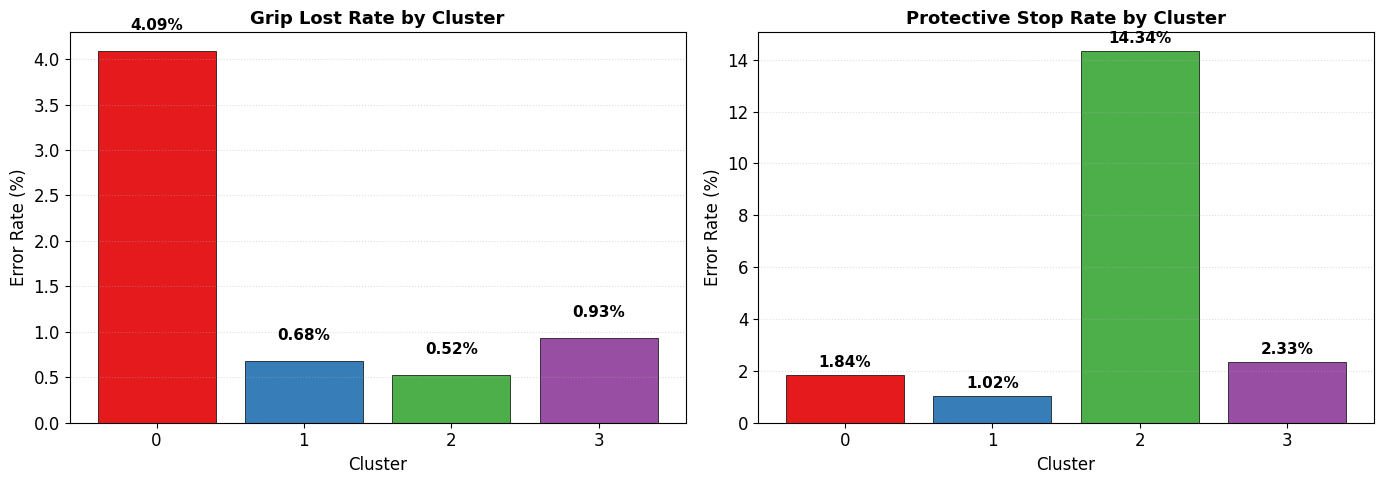


[외부 검증 지표]
  ARI = 0.0489  (1=완벽일치, 0=랜덤)
  NMI = 0.0474  (1=완벽일치, 0=무관)

[교차표] Cluster vs Error Type
error_type    GripLost  Normal  ProtectiveStop  Total
KM_Cluster_A                                         
0                  233    5360             102   5695
1                    2     289               3    294
2                    6     980             165   1151
3                    2     208               5    215
Total              243    6837             275   7355


In [20]:
# ── 최적 그룹의 군집 vs 에러 라벨 ──
# (Group A가 최적인 경우 기준. 다르면 best_labels/best_k를 교체)
best_labels = labels_A
best_k = OPTIMAL_K_A
best_col = 'KM_Cluster_A'

# 군집별 에러 발생률
error_rows = []
for c_id in range(best_k):
    subset = df_clean[df_clean[best_col] == c_id]
    n = len(subset)
    error_rows.append({
        'Cluster': c_id, 'Total': n,
        'Grip Lost (%)': round(subset['grip_lost'].sum() / n * 100, 2),
        'Protective Stop (%)': round(subset['ProtectiveStop_bool'].sum() / n * 100, 2)
    })

df_error = pd.DataFrame(error_rows).set_index('Cluster')
print("=" * 60)
print("[외부 검증] K-Means 최적 그룹 — 군집별 에러 발생률")
print("=" * 60)
print(df_error.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set1(range(best_k))

for idx, (col, title) in enumerate([
    ('Grip Lost (%)', 'Grip Lost Rate by Cluster'),
    ('Protective Stop (%)', 'Protective Stop Rate by Cluster')
]):
    ax = axes[idx]
    bars = ax.bar(df_error.index.astype(str), df_error[col],
                  color=colors, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, df_error[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster'); ax.set_ylabel('Error Rate (%)')
    ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# ARI / NMI
df_valid = df_clean.copy()
df_valid['error_label'] = 0
df_valid.loc[df_valid['ProtectiveStop_bool'], 'error_label'] = 1
df_valid.loc[df_valid['grip_lost'], 'error_label'] = 2

ari = adjusted_rand_score(df_valid['error_label'], df_valid[best_col])
nmi = normalized_mutual_info_score(df_valid['error_label'], df_valid[best_col])

print(f"\n[외부 검증 지표]")
print(f"  ARI = {ari:.4f}  (1=완벽일치, 0=랜덤)")
print(f"  NMI = {nmi:.4f}  (1=완벽일치, 0=무관)")

# 교차표
print(f"\n[교차표] Cluster vs Error Type")
error_map = {0: 'Normal', 1: 'ProtectiveStop', 2: 'GripLost'}
df_valid['error_type'] = df_valid['error_label'].map(error_map)
ct = pd.crosstab(df_valid[best_col], df_valid['error_type'], margins=True, margins_name='Total')
print(ct)